In [ ]:
pip install tensorflow

Number of classes: 46


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4158 - loss: 2.3358 - val_accuracy: 0.6483 - val_loss: 1.5089
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7514 - loss: 1.0450 - val_accuracy: 0.6912 - val_loss: 1.3128
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9406 - loss: 0.3355 - val_accuracy: 0.6850 - val_loss: 1.3629
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9622 - loss: 0.2006 - val_accuracy: 0.6962 - val_loss: 1.3589
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.1497 - val_accuracy: 0.6912 - val_loss: 1.3908
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9674 - loss: 0.1267 - val_accuracy: 0.6873 - val_loss: 1.4178
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9676 - loss: 0.1118 - val_accuracy: 0.6889 - val_loss: 1.4322
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9713 - loss: 0.0997 - val_accuracy: 0

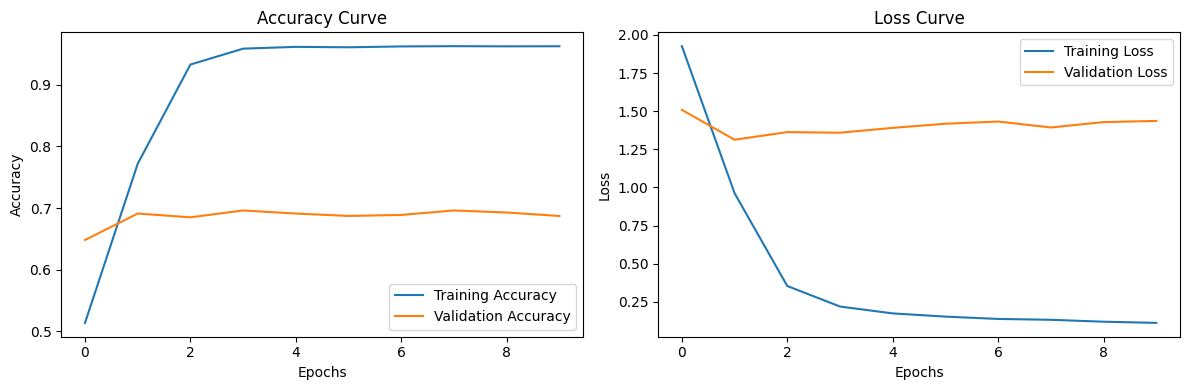


Test Accuracy: 0.6829919815063477
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Inference on Test Samples:

Sample 1: Predicted Class = 3, Actual Class = 3
Sample 2: Predicted Class = 1, Actual Class = 10
Sample 3: Predicted Class = 16, Actual Class = 1
Sample 4: Predicted Class = 3, Actual Class = 4
Sample 5: Predicted Class = 13, Actual Class = 4


In [ ]:
from typing import Sequence
#week6 of Deeplearning lab
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

num_words = 10000
max_len = 200
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=num_words)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
num_classes = np.max(y_train) + 1
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)
print("Number of classes:", num_classes)

model = Sequential([
    Embedding(num_words, 128, input_length=max_len),
    Flatten(), Dense(128,activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(
x_train, y_train, epochs=10, batch_size=64, validation_split=0.2
)

plt.figure(figsize=(12,4))
# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()
# -----------------------------------------------------------
# Step 6: Model Evaluation
# -----------------------------------------------------------
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print("\nTest Accuracy:", test_accuracy)
# -----------------------------------------------------------
# Step 7: Inference Examples
# -----------------------------------------------------------
predictions = model.predict(x_test)
print("\nInference on Test Samples:\n")
for i in range(5):
  predicted_class = np.argmax(predictions[i])
  actual_class = np.argmax(y_test[i])
  print(f"Sample {i+1}: Predicted Class = {predicted_class}, Actual Class = {actual_class}")
